<a href="https://colab.research.google.com/github/7-atharva/3D-Portfolio-Website/blob/main/Aurafinlab(LSTM_using_Pytorch).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch                                          # Imports the core PyTorch deep learning framework
import torch.nn as nn                                 # Imports PyTorch's neural network modules like layers and loss functions
import numpy as np                                    # Imports NumPy for handling numerical arrays efficiently
import pandas as pd                                   # Imports Pandas to manage tables and datasets
import yfinance as yf                                 # Imports Yahoo Finance to download live stock market data
from sklearn.preprocessing import MinMaxScaler        # Used to normalize data. (Imports the scaler to reshape data numbers between 0 and 1)
import plotly.graph_objects as go                     # Imports Plotly to draw beautiful, interactive web graphs

# ==========================================================
# 1. FETCH REAL DATA USING YFINANCE
# ==========================================================
print("Fetching real-time data for Delhivery Limited from yfinance...")
ticker = "DELHIVERY.NS"                               # Defines the National Stock Exchange ticker code for Delhivery
stock_data = yf.download(ticker, start="2022-01-01")  # Downloads all historical daily stock data from Jan 1st, 2022 to today

# Keep only the closing prices and drop empty rows
df = stock_data[['Close']].dropna()                    # Extracts only the 'Close' price column and deletes any blank rows
print(f"Successfully loaded {len(df)} trading rows for {ticker}.") # Prints the total number of valid days downloaded

# ==========================================================
# 2. DATA PREPROCESSING (SCALING)
# ==========================================================
# Scale prices between 0 and 1 so the network can stable its gradients
scaler = MinMaxScaler(feature_range=(0, 1))           # Initializes a scaler tool that squashes numbers to sit between 0 and 1
scaled_data = scaler.fit_transform(df.values)         # Fits the scaler onto our closing prices and converts them all to the 0-1 range

# ==========================================================
# 3. CREATE TIMELINE SLICES (30-DAY LOOKBACK)
# ==========================================================
# Increased lookback to 30 days to capture longer monthly cycles
lookback = 30                                         # Defines that our memory window will look back exactly 30 days
# Ex : lookback 30 days Day 1,2,3,4,5...31 then Day 2,3,4,5,6....32 then repeats this process Because LSTM learns from previous observations.
X_list = []                                           # Creates an empty list to store our input sequences (past 30 days)
y_list = []                                           # Creates an empty list to store our target answers (the 31st day price)

# Group data into 30-day historical sequence chunks
for i in range(len(scaled_data) - lookback):          # Loops through the entire dataset row-by-row until the end
    # Features (X): Takes days i to i+30
    X_list.append(scaled_data[i : i + lookback])      # Grabs the block of 30 historical days and saves it to our input list
    # Target (y): Takes the actual price on day 31 (index i+30)
    y_list.append(scaled_data[i + lookback])          # Grabs the actual price of the very next day and saves it to our target list
# Moving one day at a time Ex: Window 1 (1-30 -> 31) Window 2 (2-31 -> 32).... These windows become training samples.

X_arr = np.array(X_list)                              # Converts the structural input list into a solid NumPy multi-dimensional array
y_arr = np.array(y_list)                              # Converts the target list into a solid NumPy numerical array
# np.array() Lists cannot be used directly. So we convert them into arrays.

# Split into 80% Train and 20% Blind Test subsets
train_size = int(len(X_arr) * 0.80)                   # Calculates the cut-off index to separate 80% of data for model training

# Convert arrays directly into PyTorch tensors
X_train = torch.FloatTensor(X_arr[:train_size])       # Converts the first 80% of input patterns into PyTorch float numbers (Tensors)
y_train = torch.FloatTensor(y_arr[:train_size])       # Converts the first 80% of target prices into PyTorch float numbers (Tensors)
X_test = torch.FloatTensor(X_arr[train_size:])        # Saves the remaining 20% of inputs as our blind testing tensor block
y_test = torch.FloatTensor(y_arr[train_size:])        # Saves the remaining 20% of targets as our blind testing actual answer block

# ==========================================================
# 4. DEFINE THE PYTORCH LSTM ARCHITECTURE
# ==========================================================
class StockLSTM(nn.Module):                            # Creates our custom Neural Network or Creates our own LSTM model.
    def __init__(self, input_size=1, hidden_size=32, num_layers=1): # Sets up the initial internal layers of the network and It builds the architecture of our neural network before any data is processed.
        # Create an LSTM model with one input feature, 32 memory neurons to learn patterns, and one LSTM layer to process the sequential stock price data.
        # input_size = 1 means no of input feature as we have just 1 Closing Price
        # hidden_size=32 means It tells the LSTM How many memory neurons should it have?
        # Ex The LSTM has 32 small memory boxes MB_1,MB_2,...MB_32 So Each box learns diffrent Patterns like MB_1 one neuron may learn (weekly trend) Another neuron may learn monthly trend then another will learn Sudden price increase.
        # num_layers=1 means How many LSTM layers are stacked one after another. Ex : Input -> LSTM -> Output bus=2 sot if num_layer the Input -> LSTM Layer 1 -> LSTM Layer 2 -> output more no of layers means more learning capacity but longer traing time and Higher computational cost.
        super(StockLSTM, self).__init__()              # Links our custom setup functions directly with the master PyTorch structure
        # super() means connecting our model to Pytorch internal system
        # Define the main recurrent LSTM processing block
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True) # Sets up an LSTM layer with 32 memory cells
        # Define the final regression layer to translate memory cells back to a price
        self.linear = nn.Linear(hidden_size, 1)        # Sets up a linear connection layer to squash 32 outputs into 1 final price guess
        # self.liner used because LSTM Produced 32 outputs but we need only 1 price. So Linear converts 32 -> 1

    def forward(self, x):                             # Defines how data moves inside the network layers.
        lstm_out, _ = self.lstm(x)                     # Passes our 30-day sequence into the LSTM layer and captures its outputs
        # Extract the hidden memory state of the final day (day 30)
        last_day_out = lstm_out[:, -1, :]              # Isolates the hidden memory calculations of the very last day in our window sequence
        # last_day_out used because LSTM produces 30 op we only need the last one because the last day contains all the learned information.

        prediction = self.linear(last_day_out)         # Converts 32 neurons to 1 stock price in Linear layer
        return prediction                              # Returns the final mathematical price guess back to the main loop

model = StockLSTM()                                   # Creates an LSTM model that is ready for training

# ==========================================================
# 5. DEFINE LOSS FUNCTION & OPTIMIZER
# ==========================================================
criterion = nn.MSELoss()                               # Sets Mean Squared Error which Measures the difference between predicted and actual prices.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # Improves the model by updating its weights Ex: If prediction is wrong, Adam changes the weights to reduce future error

# ==========================================================
# 6. MODEL TRAINING LOOP (200 EPOCHS Means Model learns 200 times from the same data)
# ==========================================================
epochs = 200                                          # Configures the training loop to run through our entire data table 200 times total

print("\nStarting LSTM Training Loop...")
for epoch in range(epochs):                           # Begins the full iterative training cycle from epoch 0 up to 199
    model.train()                                     # Puts Model in learning mode (Tells our network model that it is currently in training/learning mode)
    optimizer.zero_grad()                             # Erases previous parameter gradient memories so we start this lap with a clean slate

    predictions = model(X_train)                       # Feeds the 80% training sequences forward into the model to generate pricing guesses
    loss = criterion(predictions, y_train)             # Compares those model guesses with the actual historical prices to calculate our total error

    loss.backward()                                   # Backward pass: Runs the math backward to discover how to adjust our network parameters
    #Backward Pass : It is Very Important LSTM traces where the error came from. Then calculates how much each weight should change. This is called Backpropagation.

    optimizer.step()                                  # Apply updates: Adjust the model's internal weights to reduce errors on the next lap

    # Updated to print output tracking dynamically out of 200 total loops
    if (epoch + 1) % 10 == 0:                         # Checks if our current loop number is divisible by 10 (every 10th epoch)
        print(f"Epoch [{epoch+1}/{epochs}] -> Training Loss (MSE): {round(loss.item(), 6)}") # Logs our progress to the screen safely

# ==========================================================
# 7. BLIND OUT-OF-SAMPLE TESTING
# ==========================================================
model.eval()                                          # Stops learning now only predicts.
with torch.no_grad():                                 # Deactivates gradient tracking tracking engines to save system memory and speed up computation
    test_guesses = model(X_test)                      # Hands our 20% unseen test data to the model and collects all blind price predictions

# Invert numbers back to real Indian Rupee stock prices
actual_test_prices = scaler.inverse_transform(y_test.numpy()) # Inverts our test answers from 0-1 decimals back to actual historical INR stock prices

predicted_test_prices = scaler.inverse_transform(test_guesses.numpy()) # Inverts our model predictions from 0-1 decimals back to actual INR stock prices
#Ex : 0.62 -> 450 called Inverse scaling so we can understand the prediction
final_actual = actual_test_prices[-1][0]               # Extracts the absolute latest actual closing price from our test set
final_pred = predicted_test_prices[-1][0]             # Extracts the absolute latest prediction guess from our model

print("\n" + "="*65)
print(f"LSTM FINANCIAL EXERCISE COMPLETED FOR {ticker}!")
print("="*65)
print(f"Most Recent Actual Closing Price   : Rs. {round(float(final_actual), 2)}")  # Prints actual newest stock close price
print(f"Most Recent LSTM Predicted Price   : Rs. {round(float(final_pred), 2)}")    # Prints model's newest predicted stock price
print(f"Final Absolute Modeling Variance   : Rs. {round(abs(final_actual - final_pred), 2)}") # Prints absolute error difference in rupees
print("="*65)

# ==========================================================
# 8. INTERACTIVE VISUALIZATION
# ==========================================================
print("Generating interactive visualization graph...")
test_dates = df.index[train_size + lookback:]          # Extracts corresponding timestamp index labels matching our test records timeline

fig_lstm = go.Figure()                                # Creates an empty graphical figure window frame using Plotly

# Plot actual prices
fig_lstm.add_trace(go.Scatter(                        # Adds a data line trace layer to our blank Plotly figure frame
    x=test_dates, y=actual_test_prices.flatten(),     # Maps dates to x-axis and flat actual closing prices onto our y-axis
    mode='lines', name='Actual Delhivery Close',      # Configures line plot layout settings with a professional tracker label
    line=dict(color='#FF9900', width=3),              # Renders the actual close line in a solid, clean orange color profile
    hovertemplate="<b>Date:</b> %{x}<br><b>Actual Price:</b> ₹%{y:.2f}<extra></extra>" # Formats the interactive pop-up text box layout
))

# Plot predicted prices
fig_lstm.add_trace(go.Scatter(                        # Adds our second data line trace layer onto that same canvas layout
    x=test_dates, y=predicted_test_prices.flatten(),  # Maps dates to x-axis and our model's flat prediction prices onto our y-axis
    mode='lines', name='LSTM Predicted Close',        # Configures name indicators for trace chart recognition filters
    line=dict(color='#0033CC', width=2.5, dash='dash'), # Renders the model prediction path as a clean, blue dashed vector line
    hovertemplate="<b>Date:</b> %{x}<br><b>LSTM Prediction:</b> ₹%{y:.2f}<extra></extra>" # Formats our prediction interactive text hover labels
))

# Update graph styling details
fig_lstm.update_layout(                               # Alters structural canvas sizing parameters, themes, and labeling fonts
    title=f"<b>PyTorch LSTM Exercise: Actual vs. Predicted Closing Prices (30-Day Lookback / 200 Epochs)</b>", # Sets main title
    xaxis_title="<b>Trading Date</b>", yaxis_title="<b>Stock Price (INR)</b>", # Sets text axis title headers securely
    hovermode="x unified", template="plotly_white",  # Configures professional theme background templates and crosshair hovers
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1) # Places horizontal legend cleanly above the graph canvas
)

fig_lstm.show()                                       # Instructs your system to open your default browser and launch the dashboard graph

/tmp/ipykernel_5139/1438461593.py:14: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Fetching real-time data for Delhivery Limited from yfinance...
Successfully loaded 1019 trading rows for DELHIVERY.NS.

Starting LSTM Training Loop...


Epoch [10/200] -> Training Loss (MSE): 0.024429
Epoch [20/200] -> Training Loss (MSE): 0.012902
Epoch [30/200] -> Training Loss (MSE): 0.004633
Epoch [40/200] -> Training Loss (MSE): 0.001695
Epoch [50/200] -> Training Loss (MSE): 0.001256
Epoch [60/200] -> Training Loss (MSE): 0.001005
Epoch [70/200] -> Training Loss (MSE): 0.000964
Epoch [80/200] -> Training Loss (MSE): 0.000912
Epoch [90/200] -> Training Loss (MSE): 0.000883
Epoch [100/200] -> Training Loss (MSE): 0.000857
Epoch [110/200] -> Training Loss (MSE): 0.000832
Epoch [120/200] -> Training Loss (MSE): 0.00081
Epoch [130/200] -> Training Loss (MSE): 0.00079
Epoch [140/200] -> Training Loss (MSE): 0.000773
Epoch [150/200] -> Training Loss (MSE): 0.000758
Epoch [160/200] -> Training Loss (MSE): 0.000745
Epoch [170/200] -> Training Loss (MSE): 0.000734
Epoch [180/200] -> Training Loss (MSE): 0.000722
Epoch [190/200] -> Training Loss (MSE): 0.000711
Epoch [200/200] -> Training Loss (MSE): 0.000699

LSTM FINANCIAL EXERCISE COMPLE

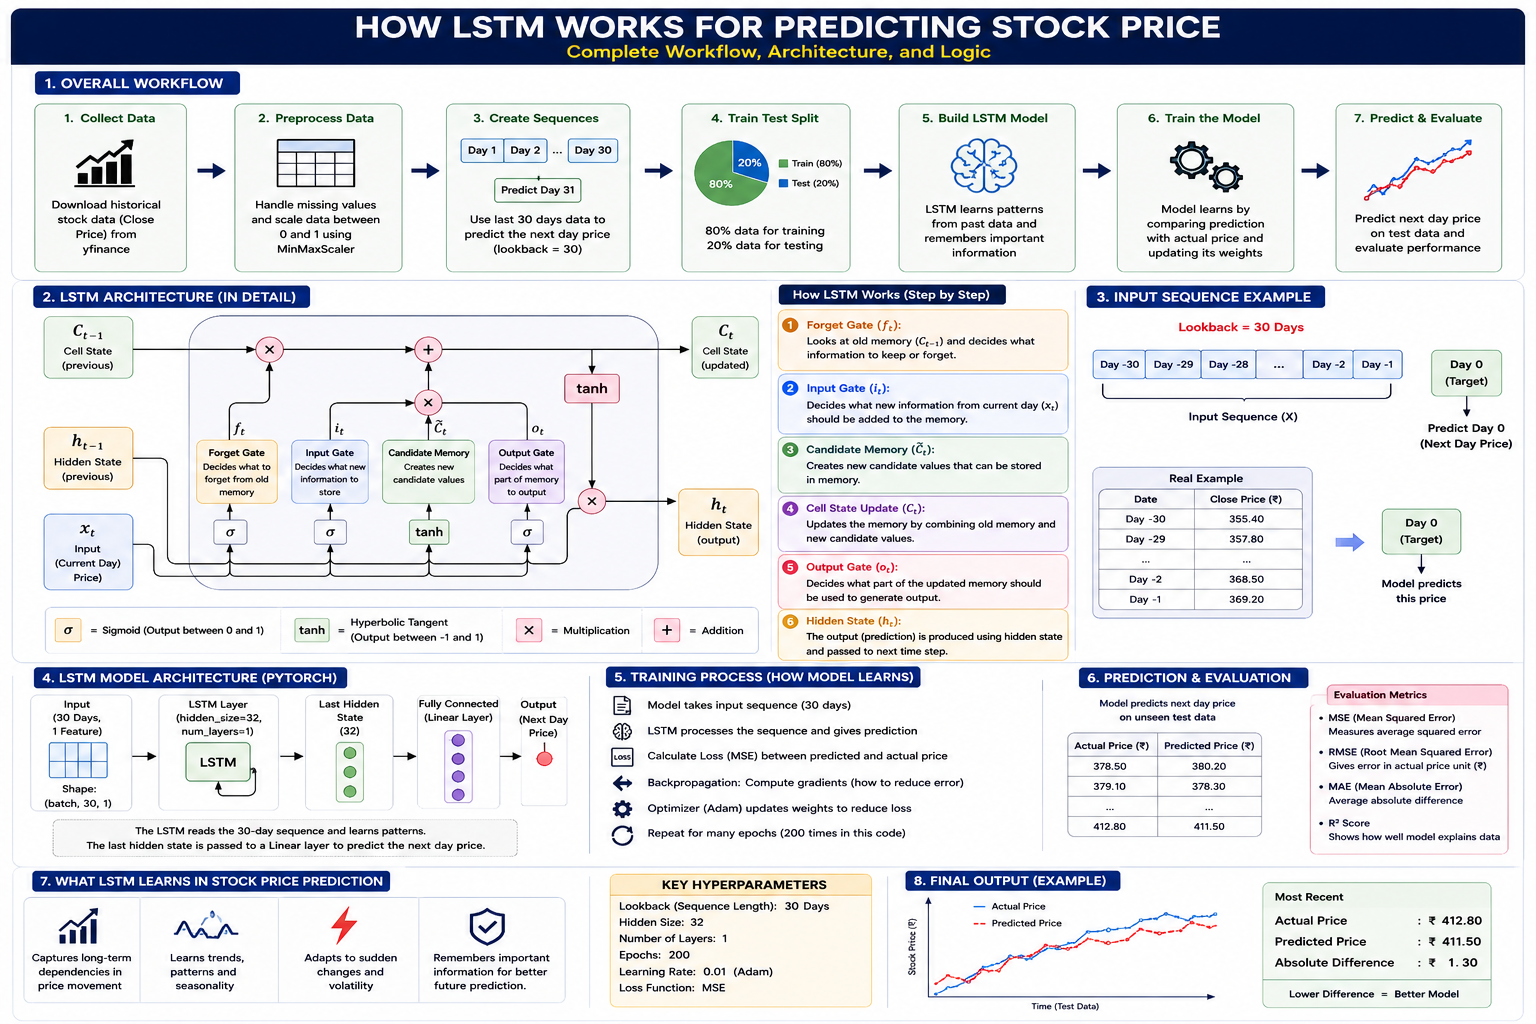